In [1]:
#!/usr/bin/env python3.11
# -*- coding: utf-8 -*-

import PIL
import PIL.Image
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import os
from skimage.filters import gaussian

def load_npz_file(fn):
    filename, file_extension = os.path.splitext(fn)
    if file_extension == '.npz' or os.path.exists(filename + '.npz'):
        npz_file = np.load(fn,allow_pickle=True)
        E_xy_histo = npz_file['E_xy']
        return E_xy_histo


def generate_bounding_boxes(grid_size, box_size, offset, spacing, pads):
    positions = {}
    rows, cols = grid_size
    box_h, box_w = box_size
    x_offset, y_offset = offset
    x_spacing, y_spacing = spacing

    count = 1
    for i in range(rows):
        for j in range(cols):
            x1 = x_offset + i * (box_h + x_spacing)
            x2 = x1 + box_h
            y1 = y_offset + j * (box_w + y_spacing)
            y2 = y1 + box_w
            positions[pads[i*cols + j]] = (x1, x2, y1, y2)
            count += 1
    
    return positions
    

In [5]:
pads_e_xy = load_npz_file("data/objects/pigment_palette/GEM_Cr_PBS1_PadsPalette_ArCO2_80_20_Gain_35_Thr_35_HV3490_Xray_50kV_1mA_Pinhol_2mm_sum_3-23_GainCorr_Fe.npz")
pads_e_xy = np.fliplr(np.rot90(pads_e_xy, k=1))

pad_names = [
    "mn_fe",          # Umbra
    "ca_zn",          # Żółta neapolitańska ???
    "s_as_ca_zn",     # Aurypigment
    "ca_zn_pb",       # Żółta neapolitańska ???
    "mn",             # Fiolet manganowy
    
    "s_hg",           # Umbra
    "wood",           # Deska (Drewno)
    "cr",             # Zieleń chromowa
    "ti",             # Biel tytanowa
    "s_as",           # Realgar (Madryt)

    "si_zr",          # Ceruleum
    "fe",             # Raw Siena
    "na_al_si_s",     # Ultramaryna
    "s_k_cd",         # Żółta kadmowa
    "si_k_co",        # Smalta

    "sn_pb",          # Żółta cynowo-ołowiowa
    "cu",             # Malachit
    "pb",             # Minia ołowiowa
    "ag",             # Srebro
    "al",             # Aluminium

    "s_zn",           # Biel cynkowa
    "co",             # Niebieski kobaltowy
    "s_ba",           # Biel barytowa
    "s_au",           # Złoto
    "cu_zn"           # Mosiądz
]

['mn_fe', 'ca_zn', 'as_ca_zn', 'ca_zn_pb', 'mn', 'hg', 'wood', 'cr', 'ti', 'as', 'zr', 'fe', '', 'k_cd', 'k_co', 'sn_pb', 'cu', 'pb', '', '', 'zn', 'co', 'ba', 'au', 'cu_zn']
{'mn_fe': (9, 25, 9, 25), 'ca_zn': (9, 25, 31, 47), 's_as_ca_zn': (9, 25, 53, 69), 'ca_zn_pb': (9, 25, 75, 91), 'mn': (9, 25, 97, 113), 's_hg': (31, 47, 9, 25), 'wood': (31, 47, 31, 47), 'cr': (31, 47, 53, 69), 'ti': (31, 47, 75, 91), 's_as': (31, 47, 97, 113), 'si_zr': (53, 69, 9, 25), 'fe': (53, 69, 31, 47), 'na_al_si_s': (53, 69, 53, 69), 's_k_cd': (53, 69, 75, 91), 'si_k_co': (53, 69, 97, 113), 'sn_pb': (75, 91, 9, 25), 'cu': (75, 91, 31, 47), 'pb': (75, 91, 53, 69), 'ag': (75, 91, 75, 91), 'al': (75, 91, 97, 113), 's_zn': (97, 113, 9, 25), 'co': (97, 113, 31, 47), 's_ba': (97, 113, 53, 69), 's_au': (97, 113, 75, 91), 'cu_zn': (97, 113, 97, 113)}
(48, 48, 4096)
dict_keys(['ca_zn', 'mn', 'hg', 'wood', 'cr', 'ti', 'as', 'zr', 'fe', 'k_cd', 'k_co', 'cu', 'pb', 'zn', 'co', 'ba', 'au'])


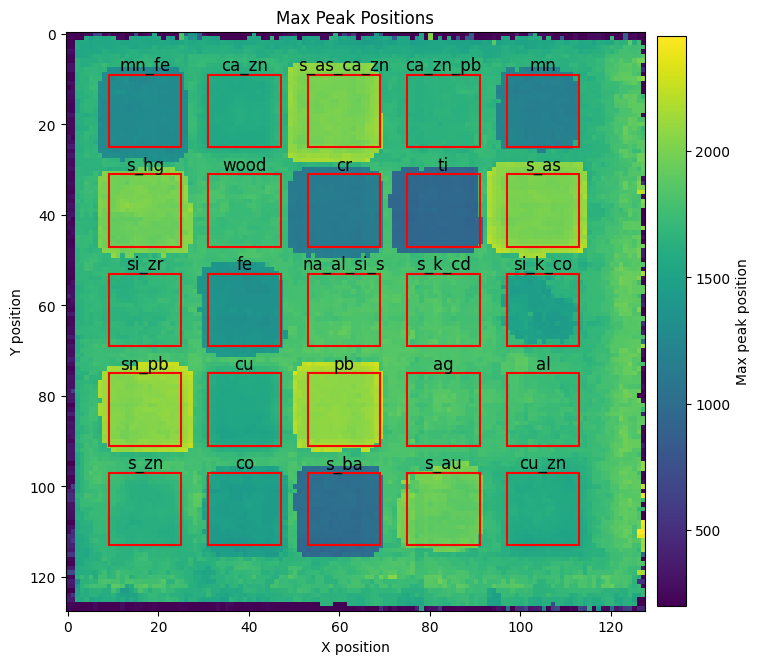

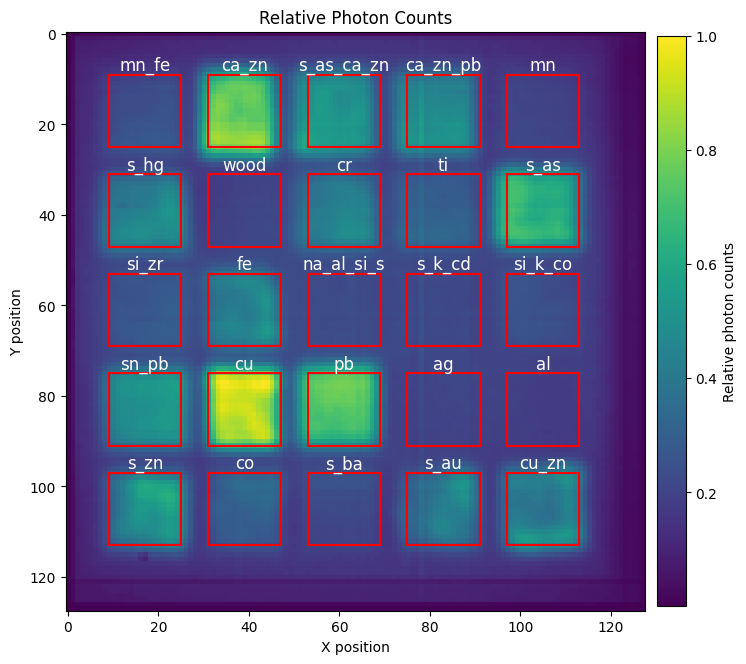

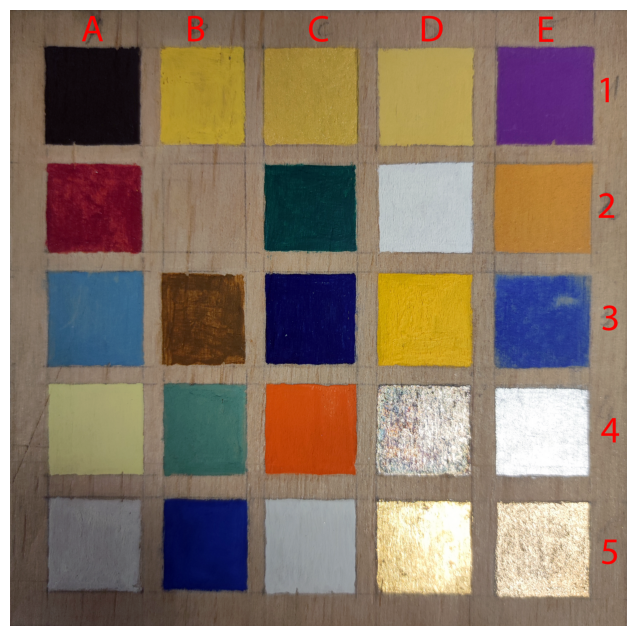

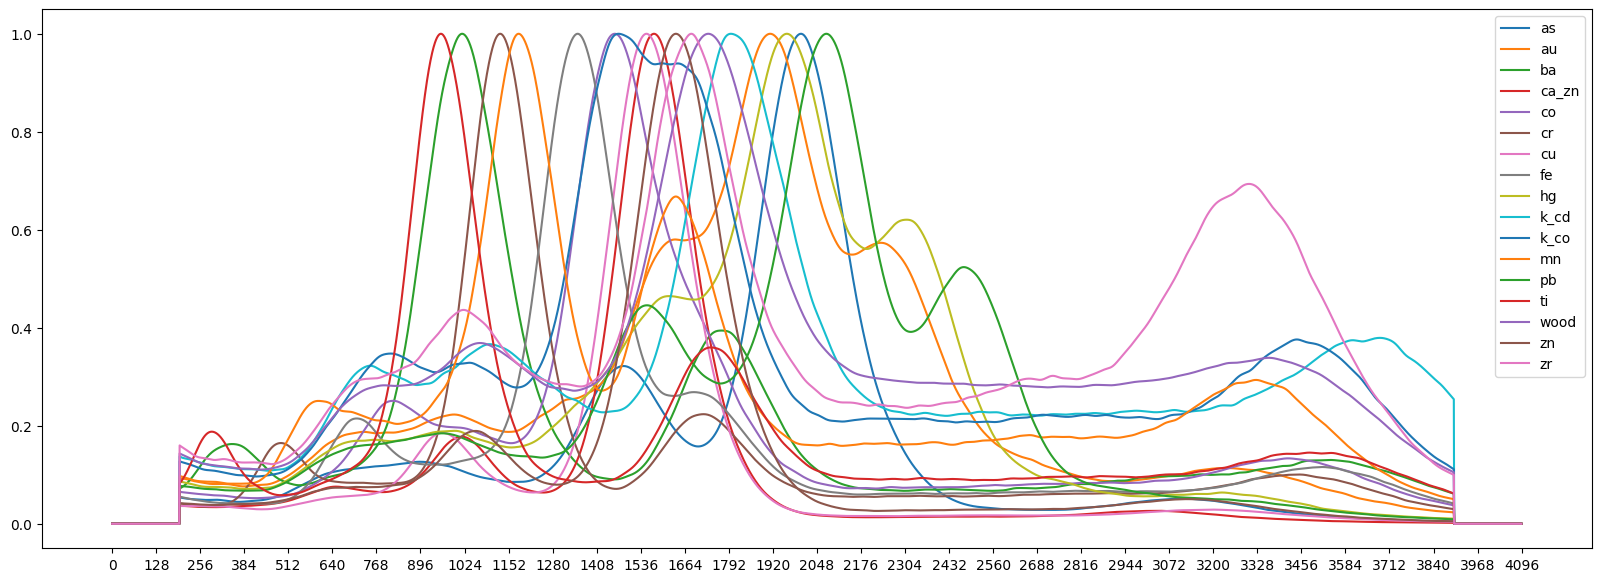

In [ ]:
# # - W detektorze GEM_Cr zupełnie nie zaobserwuję zewnętrznego!!! sygnału od: Al, Ag, S, Si, Na, Sn

# max_E = 2048
# bins_short = np.arange(0, 2 * max_E)[:-2]

def filtered_element_name(pad_name, excluded_elements):
    return "_".join([name for name in pad_name.split("_") if name not in excluded_elements])

def apply_smoothing_and_padding(pads_e_xy, padding_size):
    smoothed_pads_e_xy = gaussian(pads_e_xy, sigma=0.6)
    smoothed_pads_e_xy = np.apply_along_axis(
        gaussian, axis=2, arr=smoothed_pads_e_xy, sigma=16, preserve_range=True
    )
    smoothed_pads_e_xy[:, :, :padding_size] = 0
    smoothed_pads_e_xy[:, :, -padding_size:] = 0

    return smoothed_pads_e_xy 

def select_pads(pads_e_xy, pad_positions, E_shift):
    selected_pads = {
        name: pads_e_xy[x1:x2, y1:y2].astype(float) / (1 << E_shift)
        for name, (x1, x2, y1, y2) in pad_positions.items()
    }

    mask = np.ones_like(pads_e_xy, dtype=bool)
    for name, (x1, x2, y1, y2) in pad_positions.items():
        mask[x1-4:x2+4, y1-4:y2+4] = False if name != "wood" else True

    wood_pad = (pads_e_xy[4:-4, 4:-4][mask[4:-4, 4:-4]].astype(float) / (1 << E_shift)).reshape(-1, pads_e_xy.shape[-1])
    square_side = int(np.sqrt(wood_pad.shape[0]))
    wood_pad = wood_pad[:square_side**2, :].reshape(square_side, square_side, pads_e_xy.shape[-1])
    selected_pads["wood"] = wood_pad
    print(selected_pads["wood"].shape)

    return selected_pads 

def filter_pads(selected_pads, excluded_elements):
    filtered_pads = {}
    for name, pad in selected_pads.items():
        filtered_name = filtered_element_name(name, excluded_elements)
        if filtered_name != "" and filtered_name not in ["mn_fe", "cu_zn", "as_ca_zn", "ca_zn_pb", "sn_pb"]:
            filtered_pads[filtered_name] = pad
    return filtered_pads

def plot_pad_max_peak_positions(pads_e_xy, pad_positions):
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.title("Max Peak Positions")
    plt.xlabel("X position")
    plt.ylabel("Y position")
    pads_map = np.argmax(pads_e_xy, axis=2)
    im = ax.imshow(pads_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Max peak position")
    
    for pad_name, (x1, x2, y1, y2) in pad_positions.items():
        width, height = y2 - y1, x2 - x1
        rect = patches.Rectangle((y1, x1), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(y1 + width // 2, x1 - 2, pad_name, color='black', fontsize=12, ha='center', va='center')
    plt.savefig("data/plots/max_peak_positions.svg", bbox_inches='tight',  pad_inches=0)

def plot_pad_photon_counts(pads_e_xy, pad_positions):
    fig, ax = plt.subplots(figsize=(8, 8))
    plt.title("Relative Photon Counts")
    plt.xlabel("X position")
    plt.ylabel("Y position")

    pads_map = np.sum(pads_e_xy, axis=2)
    pads_map /= np.max(pads_map)

    im = ax.imshow(pads_map, cmap="viridis")
    cbar = plt.colorbar(im, ax=ax, pad=0.02, fraction=0.046)
    cbar.set_label("Relative photon counts")
    
    for pad_name, (x1, x2, y1, y2) in pad_positions.items():
        width, height = y2 - y1, x2 - x1
        rect = patches.Rectangle((y1, x1), width, height, linewidth=1.5, edgecolor='red', facecolor='none')
        ax.add_patch(rect)
        ax.text(y1 + width // 2, x1 - 2, pad_name, color='white', fontsize=12, ha='center', va='center')
    plt.savefig("data/plots/photon_counts.svg", bbox_inches='tight',  pad_inches=0)

def plot_palette_image(image_path):
    plt.figure(123, figsize=(8, 8))
    img = PIL.Image.open(image_path)
    plt.imshow(img, alpha=1)
    plt.axis('off')

def plot_pads(selected_pads):
    plt.figure(figsize=(20, 7))
    
    sorted_pads = dict(sorted(selected_pads.items()))

    for name, pad_e_xy in sorted_pads.items():
        pad_avg = np.mean(pad_e_xy, axis=(0, 1))
        plt.plot(pad_avg / np.max(pad_avg), label=name)
    plt.xticks(np.arange(0, 4097, 128))
    plt.legend()

E_shift = 2
excluded_elements = {"al", "ag", "s", "si", "na"}
padding_size = 196  
grid_size = (5, 5)
box_size = (16, 16)
offset = (9, 9)
spacing = (6, 6)
image_path = "data/pigment_palette/pads_palette_photo.png"

print([filtered_element_name(name, excluded_elements) for name in pad_names])

padded_pads_e_xy = apply_smoothing_and_padding(pads_e_xy, padding_size)
    

pad_positions = generate_bounding_boxes(grid_size, box_size, offset, spacing, pad_names)
print(pad_positions)

selected_pads = select_pads(padded_pads_e_xy, pad_positions, E_shift)
filtered_pads = filter_pads(selected_pads, excluded_elements)
print(filtered_pads.keys())

plot_pad_max_peak_positions(padded_pads_e_xy, pad_positions)
plot_pad_photon_counts(padded_pads_e_xy, pad_positions)
plot_palette_image(image_path)
plot_pads(filtered_pads)




17


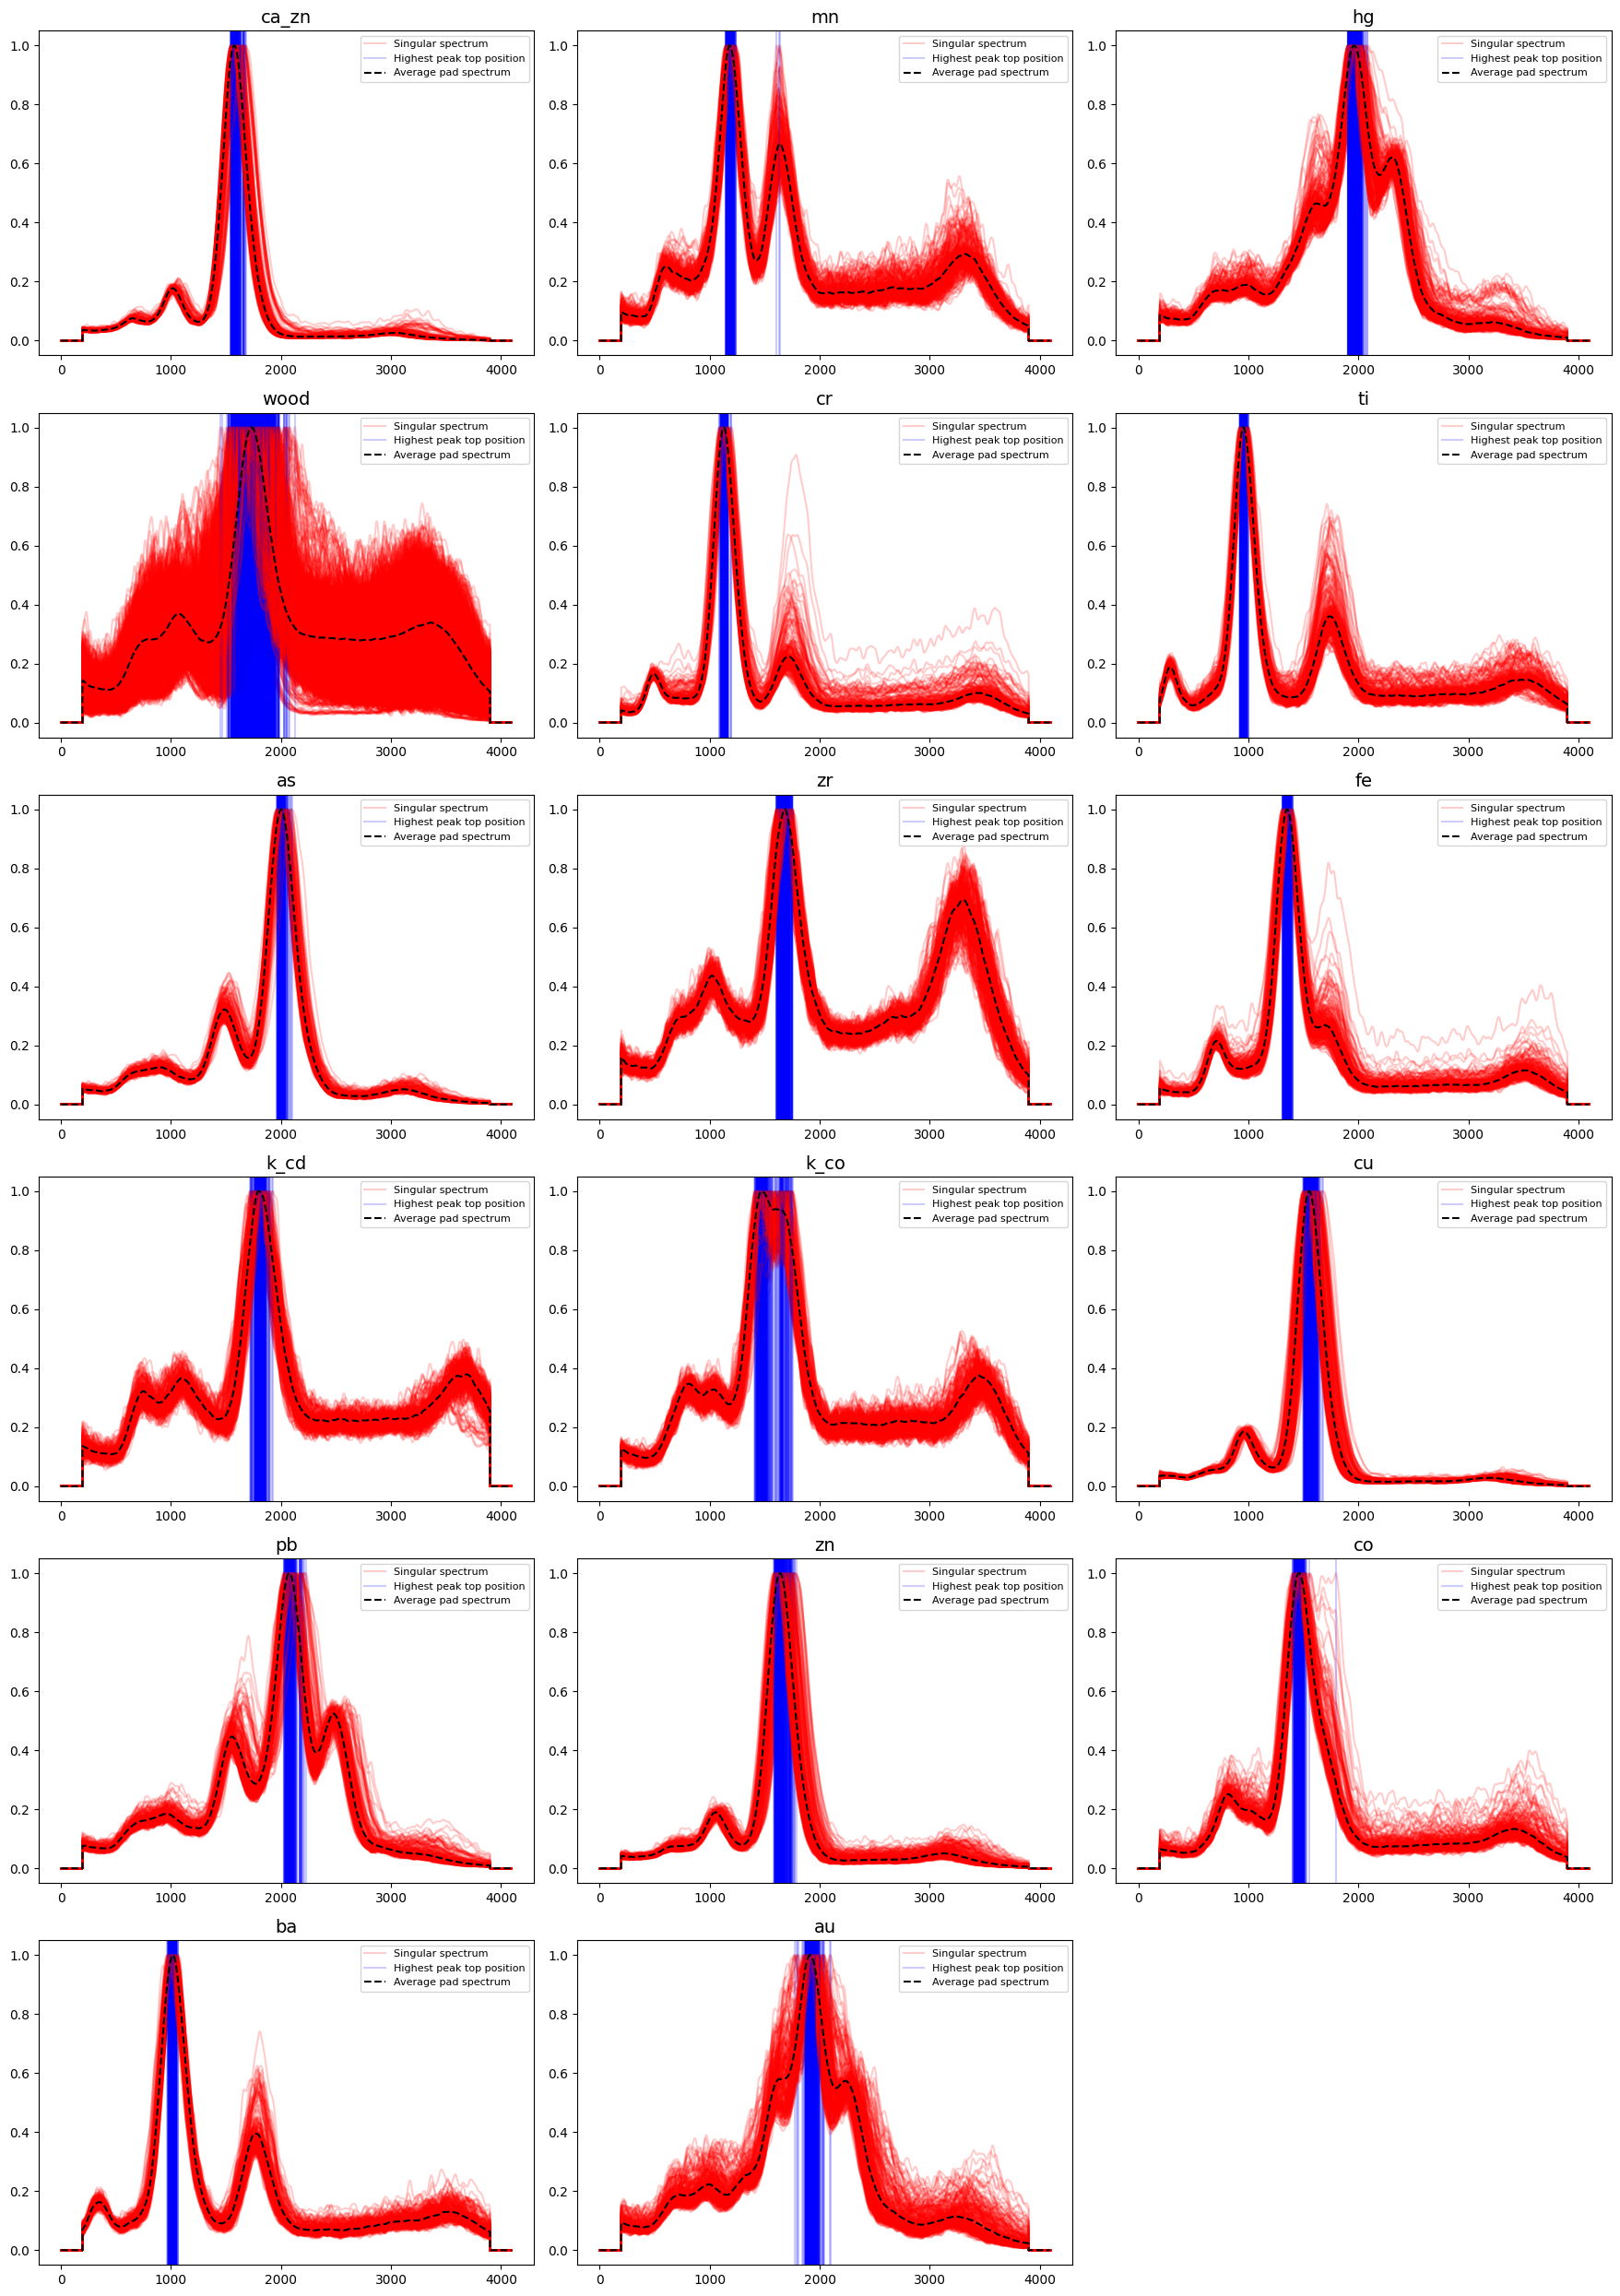

In [4]:
from random import randint 
print(len(filtered_pads.keys()))

proportion = 21/29.7
height = 25
width = height * proportion
fig, axes = plt.subplots(6, 3, figsize=(width, height))
axes = axes.flatten()

avg_pad_spectra_no_filtering = {}

for idx, (pad_name, pad) in enumerate(filtered_pads.items()):
    for i in range(pad.shape[0]):
        for j in range(pad.shape[1]):
            spectrum = pad[i][j]
            spectrum = spectrum / np.max(spectrum)
            axes[idx].plot(spectrum, color="red", alpha=0.20, label="Singular spectrum" if j == 0 and i == 0 else None) 


            first_peak_position = np.argmax(spectrum)
            axes[idx].axvline(first_peak_position, color="blue", alpha=0.2, label="Highest peak top position" if i == 0 and j == 0 else None)

    
    pad_avg_spectrum = np.average(pad, axis=(0, 1))
    pad_avg_spectrum = pad_avg_spectrum / np.max(pad_avg_spectrum)
    avg_pad_spectra_no_filtering[pad_name] = pad_avg_spectrum

    axes[idx].plot(pad_avg_spectrum, color="black", linewidth=1.5, linestyle="--", label="Average pad spectrum")

    axes[idx].set_title(pad_name, fontsize=14)
    axes[idx].legend(loc='upper right', fontsize=8)

for idx in range(idx+1, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.title("Processed Pads Spectra", fontsize=16)
plt.savefig("data/plots/spectra_of_processed_pads.png", dpi=300)

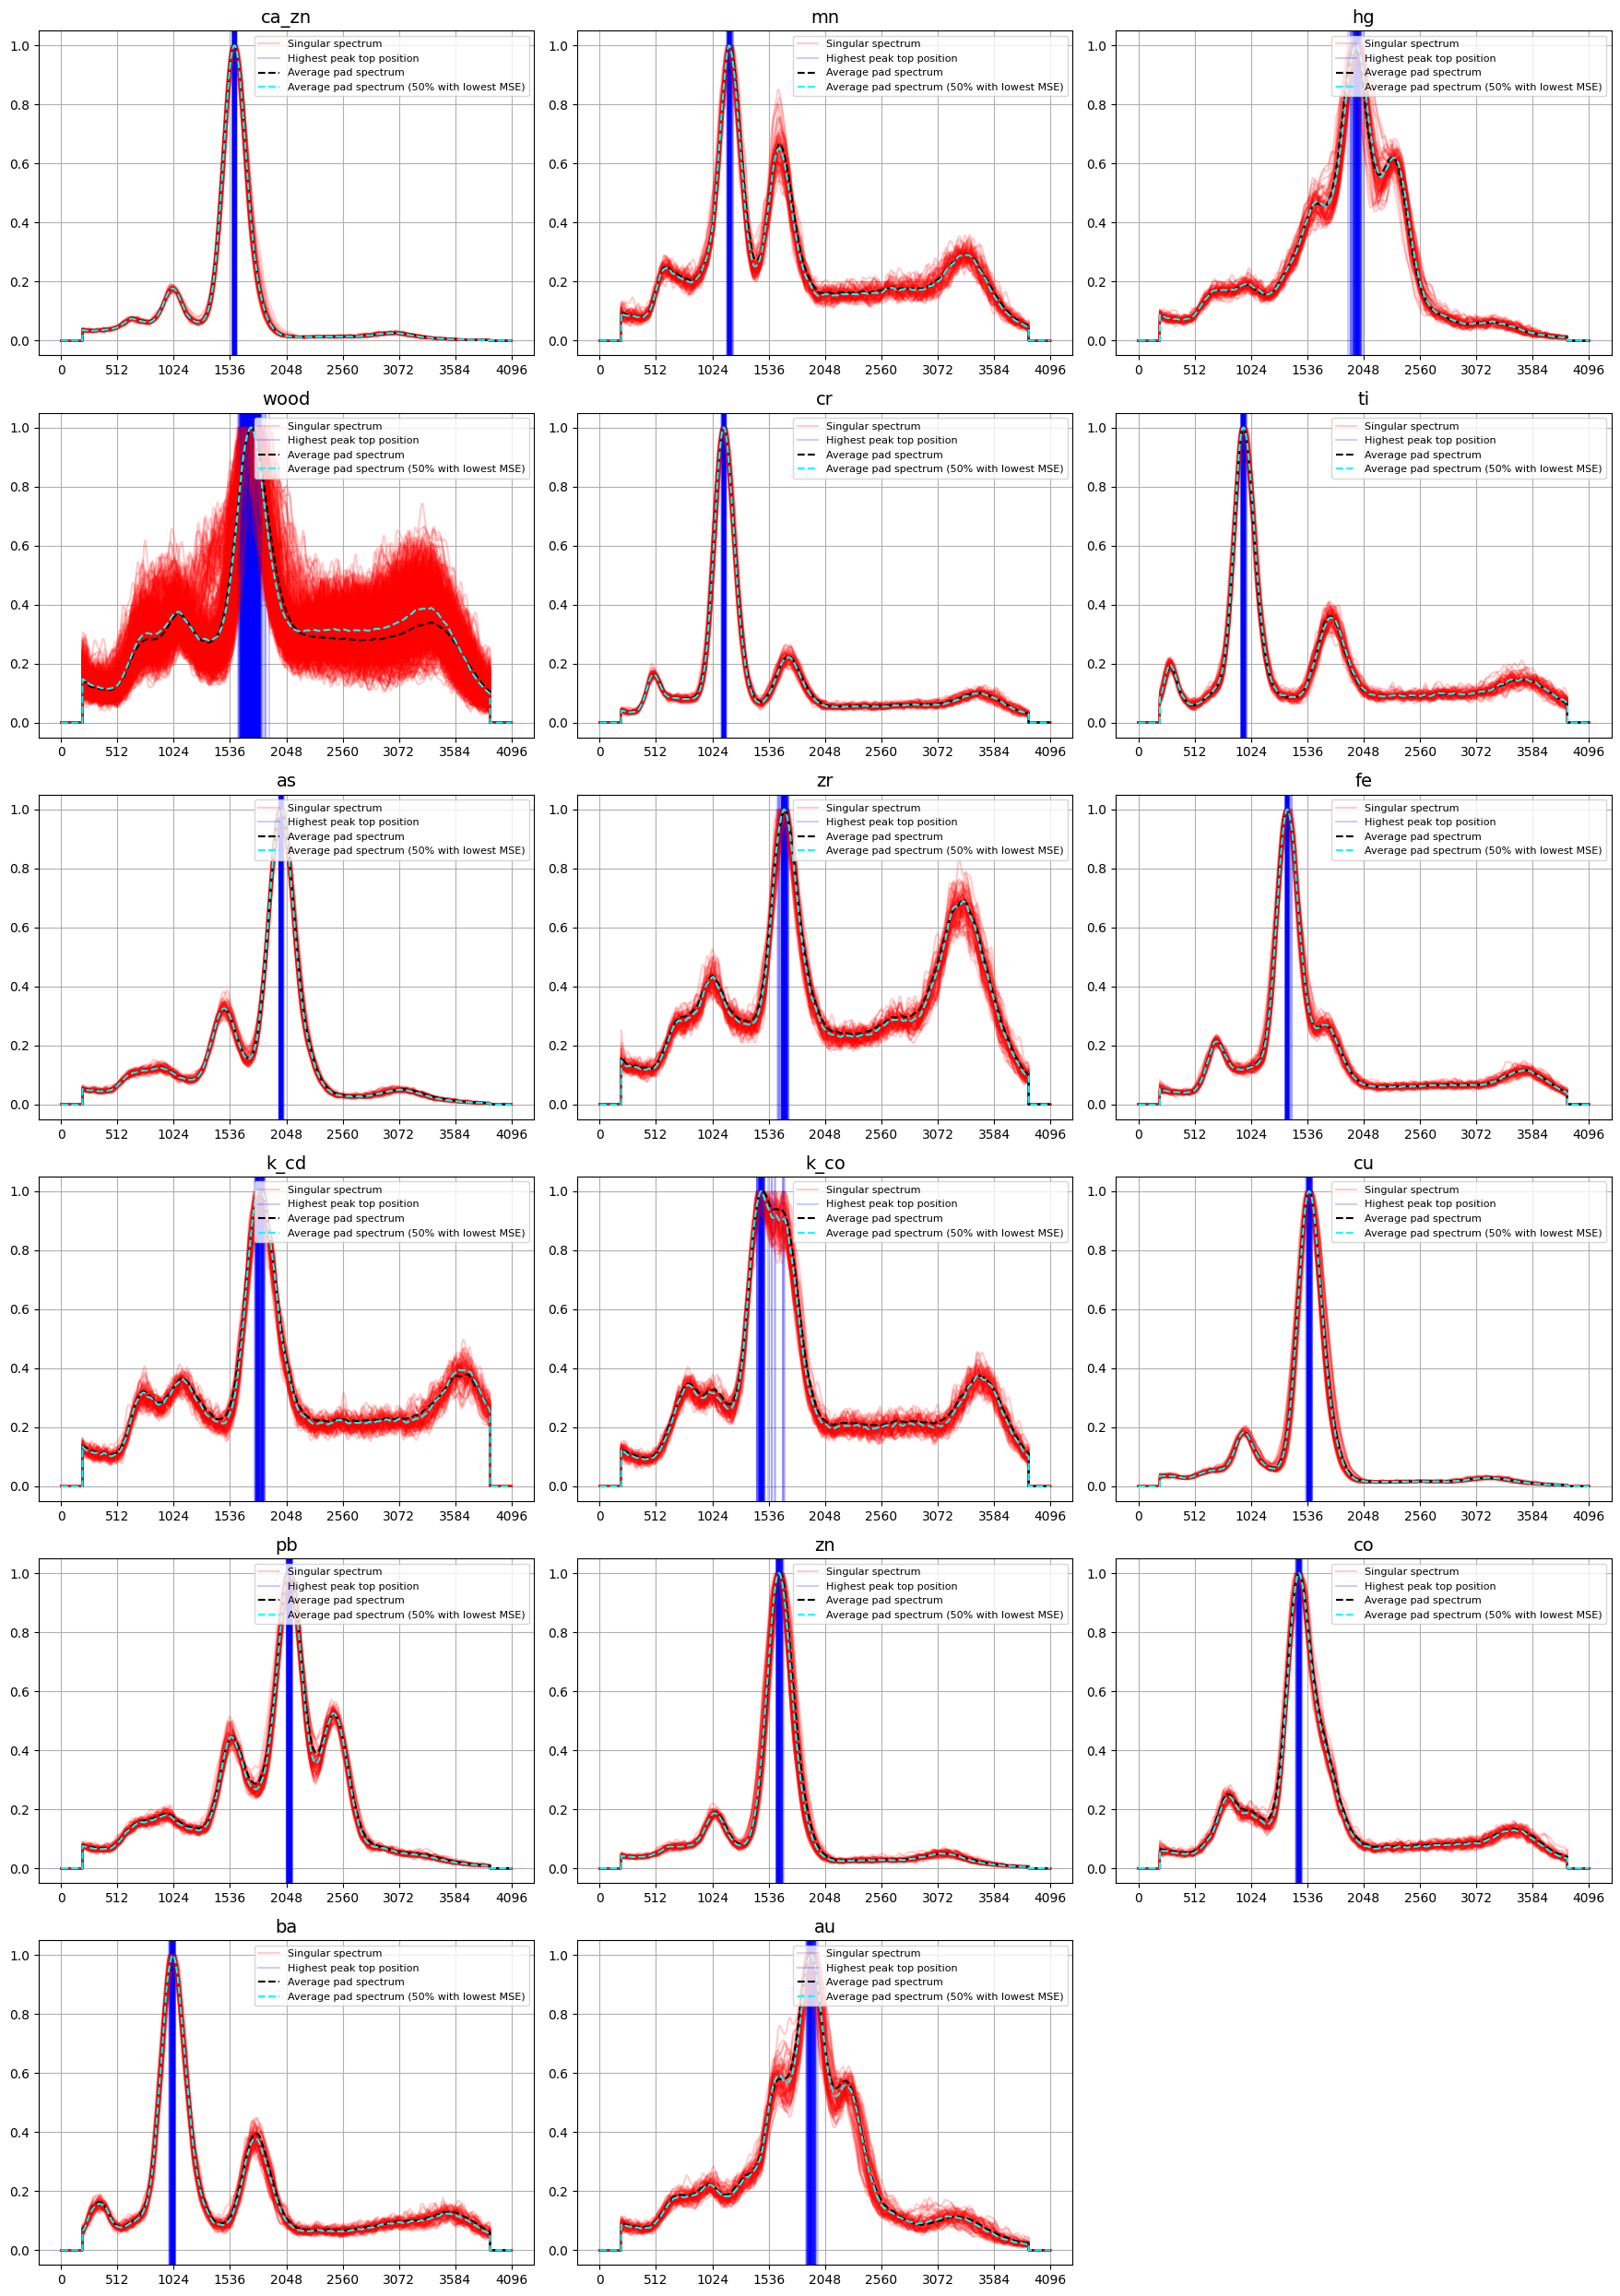

In [5]:
from sklearn.metrics import mean_squared_error
from collections import defaultdict


fig, axes = plt.subplots(6, 3, figsize=(width, height))
axes = axes.flatten()

def get_spectra_with_lowest_mse(pads: np.array, fraction_to_keep=0.25):
    mse_filtered_pads = defaultdict(list)
    for pad_name, pad in pads.items():
        pad_avg_spectrum = np.average(pad, axis=(0, 1))
        for i in range(pad.shape[0]):
            for j in range(pad.shape[1]):
                spectrum = pad[i, j]
                mse_filtered_pads[pad_name].append(((mean_squared_error(pad_avg_spectrum, spectrum), pad[i, j])))
        
        mse_filtered_pads[pad_name].sort(key=lambda x: x[0])
        mse_filtered_pads[pad_name] = np.array([x[1] for x in mse_filtered_pads[pad_name][:int(len(mse_filtered_pads[pad_name]) * fraction_to_keep)]])
    return mse_filtered_pads 

# selected_pads = select_pads(pads_e_xy, pad_positions, E_shift)
# filtered_pads = filter_pads(selected_pads, excluded_elements)
mse_filtered_pads = get_spectra_with_lowest_mse(filtered_pads)
        
result_spectra = {}

for idx, (pad_name, pad) in enumerate(mse_filtered_pads.items()):
    for i in range(pad.shape[0]):
        spectrum = pad[i]
        spectrum = spectrum / np.max(spectrum)
        axes[idx].plot(spectrum, color="red", alpha=0.2, label="Singular spectrum" if i == 0 else None)


        first_peak_position = np.argmax(spectrum)
        axes[idx].axvline(first_peak_position, color="blue", alpha=0.2, label="Highest peak top position" if i == 0 else None)


    pad_avg_spectrum = np.average(pad, axis=(0))
    pad_avg_spectrum = pad_avg_spectrum / np.max(pad_avg_spectrum)
    axes[idx].plot(avg_pad_spectra_no_filtering[pad_name], color="black", linewidth=1.5, linestyle="--", label="Average pad spectrum")
    axes[idx].plot(pad_avg_spectrum, color="cyan", linewidth=1.5, linestyle="--", label="Average pad spectrum (50% with lowest MSE)")
    result_spectra[pad_name] = pad_avg_spectrum

    axes[idx].set_title(pad_name, fontsize=14)
    axes[idx].legend(loc="upper right", fontsize=8)
    axes[idx].set_xticks(np.arange(0, 4097, 512))
    axes[idx].grid(True)

for idx in range(idx+1, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.title("Filtered Pads Spectra")
plt.savefig("data/plots/filtered_pads_spectra.png", dpi=300)

np.savez("data/pigment_palette/preprocessed_spectra.npz", **result_spectra)

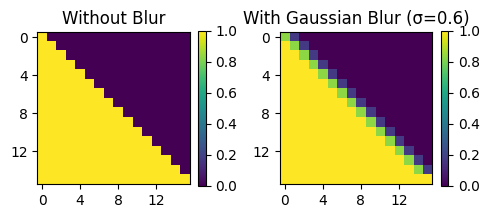

In [6]:
lower_triangle = np.tril(np.ones((16, 16), dtype=np.float32))
lwoer_traingle = lower_triangle.reshape((*lower_triangle.shape, 1))
fig, axes = plt.subplots(1, 2, figsize=(5, 3))

ax1 = axes[0]
im1 = ax1.imshow(lower_triangle)
fig.colorbar(im1, ax=ax1, fraction=0.046)
ax1.set_yticks(np.arange(0, 16, 4))  # Set integer values on y-axis
ax1.set_xticks(np.arange(0, 16, 4))  # Set integer values on x-axis

ax2 = axes[1]
im2 = ax2.imshow(gaussian(lower_triangle, sigma=0.6, channel_axis=2))
fig.colorbar(im2, ax=ax2, fraction=0.046)
ax2.set_yticks(np.arange(0, 16, 4))  # Set integer values on y-axis
ax2.set_xticks(np.arange(0, 16, 4))  # Set integer values on x-axis

plt.tight_layout()
axes[0].set_title("Without Blur")
axes[1].set_title("With Gaussian Blur (\u03C3=0.6)")
plt.savefig("data/plots/gaussian_blur_demo.svg", bbox_inches="tight", pad_inches=0.1, format="svg")
plt.show()
